In [2]:
import subprocess
subprocess.run(['pip', 'install', 'duckdb'])

CompletedProcess(args=['pip', 'install', 'duckdb'], returncode=0)

In [3]:
import duckdb
import pandas as pd

In [4]:
conn = duckdb.connect('nyc_taxi.duckdb')

In [5]:
print("DuckDB connected successfully")
print(duckdb.__version__)

DuckDB connected successfully
1.5.4


In [4]:
import os

cleaned_files = sorted([
    os.path.join('../cleaned', f) 
    for f in os.listdir('../cleaned') 
    if f.endswith('.csv')
])
print(f"Found {len(cleaned_files)} files to load")
# raw_trips table
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_trips AS 
    SELECT * FROM read_csv_auto('../cleaned/*.csv', union_by_name=True)
""")
count = conn.execute("SELECT COUNT(*) FROM raw_trips").fetchone()[0]
print(f"Loaded {count:,} rows into raw_trips")

Found 24 files to load


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 41,829,934 rows into raw_trips


# Star Schema

#### dim_payment

In [5]:
conn.execute("""
    CREATE TABLE IF NOT EXISTS dim_payment AS
    SELECT * FROM (VALUES
        (1, 1, 'Credit Card'),
        (2, 2, 'Cash'),
        (3, 3, 'No Charge'),
        (4, 4, 'Dispute'),
        (5, 5, 'Unknown'),
        (6, 6, 'Voided Trip')
    ) AS t(payment_key, payment_code, payment_desc)
""")

print("dim_payment created:", conn.execute("SELECT COUNT(*) FROM dim_payment").fetchone()[0], "rows")

dim_payment created: 6 rows


#### dim_date

In [8]:
conn.execute("""
    CREATE TABLE IF NOT EXISTS dim_date AS
    SELECT DISTINCT
        CAST(strftime(pickup_datetime, '%Y%m%d%H') AS INTEGER)  AS date_key,
        CAST(pickup_datetime AS DATE)                            AS full_date,
        date_part('year', pickup_datetime)                       AS year,
        date_part('month', pickup_datetime)                      AS month,
        strftime(pickup_datetime, '%B')                          AS month_name,
        date_part('day', pickup_datetime)                        AS day,
        date_part('hour', pickup_datetime)                       AS hour,
        date_part('dow', pickup_datetime)                        AS day_of_week,
        strftime(pickup_datetime, '%A')                          AS day_name,
        CASE WHEN date_part('dow', pickup_datetime) IN (0, 6) 
             THEN 1 ELSE 0 END                                   AS is_weekend
    FROM raw_trips
    WHERE pickup_datetime IS NOT NULL
""")

count = conn.execute("SELECT COUNT(*) FROM dim_date").fetchone()[0]
print(f"dim_date created: {count:,} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

dim_date created: 8,812 rows


#### dim_zone

In [9]:
conn.execute("""
    CREATE TABLE IF NOT EXISTS dim_zone AS
    SELECT 
        LocationID AS zone_id,
        Zone AS zone_name,
        Borough AS borough,
        service_zone
    FROM read_csv_auto('../taxi_zone_lookup.csv')
""")
count = conn.execute("SELECT COUNT(*) FROM dim_zone").fetchone()[0]
print(f"dim_zone created: {count:,} rows")

dim_zone created: 265 rows


#### fact_trips

In [10]:
conn.execute("""
    CREATE TABLE IF NOT EXISTS fact_trips AS
    SELECT strftime(pickup_datetime, '%Y%m%d%H')::INTEGER AS date_key,
    pickup_zone_id                                  AS pickup_zone_key,
    dropoff_zone_id                                 AS dropoff_zone_key,
    CASE WHEN payment_type IN (1,2,3,4,5,6) 
        THEN payment_type ELSE NULL END            AS payment_key,
    service_type,
    fare_amount,
    tip_amount,
    tolls_amount,
    total_amount,
    trip_distance,
    passenger_count,
    congestion_surcharge,
    trip_duration_min,
    speed_mph,
    fare_per_mile,
    fare_per_minute,
    tip_pct,
    is_airport_trip,
    is_dirty,
    dirty_reason
    FROM raw_trips
    WHERE pickup_datetime IS NOT NULL
""")

count = conn.execute("SELECT COUNT(*) FROM fact_trips").fetchone()[0]
print(f"fact_trips created: {count:,} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_trips created: 41,829,934 rows


# ANALYSIS

### DEMAND PATTERNS 

In [13]:
import subprocess
subprocess.run(['pip', 'install', 'matplotlib'])

CompletedProcess(args=['pip', 'install', 'matplotlib'], returncode=0)

,hour,trips
0,0,1145433
1,1,740283
2,2,480512
3,3,313774
4,4,228713
5,5,250245
6,6,565237
7,7,1105835
8,8,1526547
9,9,1672114


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Trips by Hour of Day'}, xlabel='hour'>

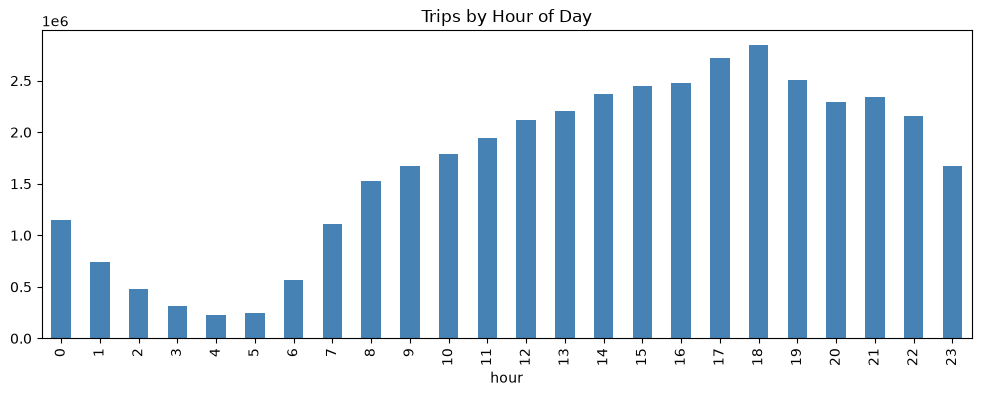

In [14]:
# Trips by Hour of Day
df_hour = conn.execute("""
    SELECT d.hour, COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.hour
    ORDER BY d.hour
""").df()

display(df_hour)

df_hour.plot(x='hour', y='trips', kind='bar', figsize=(12,4),
             title='Trips by Hour of Day', legend=False,
             color='steelblue')

In [16]:
# Trips by month
df_month = conn.execute("""
    SELECT month_name, month, COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.month, month_name
    ORDER BY d.month
""").df()

display(df_month)

,month_name,month,trips
0,January,1,2889985
1,February,2,2916708
2,March,3,3453037
3,April,4,3427095
4,May,5,3635119
5,June,6,3443641
6,July,7,2992633
7,August,8,2889101
8,September,9,3504894
9,October,10,3699037


In [20]:
# Trips by Day of the week
df_day = conn.execute("""
    SELECT d.day_name AS day_of_week, d.day_of_week, COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.day_name, d.day_of_week
    ORDER BY d.day_of_week;
""").df()

display(df_day)

,day_of_week,day_of_week_1,trips
0,Sunday,0,5098499
1,Monday,1,4970128
2,Tuesday,2,5733492
3,Wednesday,3,5947199
4,Thursday,4,6237877
5,Friday,5,5901678
6,Saturday,6,6031150


,time_period,trips,avg_fare
0,Off Peak,20116706,20.14
1,Evening Rush,10549519,19.60
2,Morning Rush,6094838,19.03
3,Late Night,3158960,19.84


<Axes: title={'center': 'Trips by Time Period'}, xlabel='time_period'>

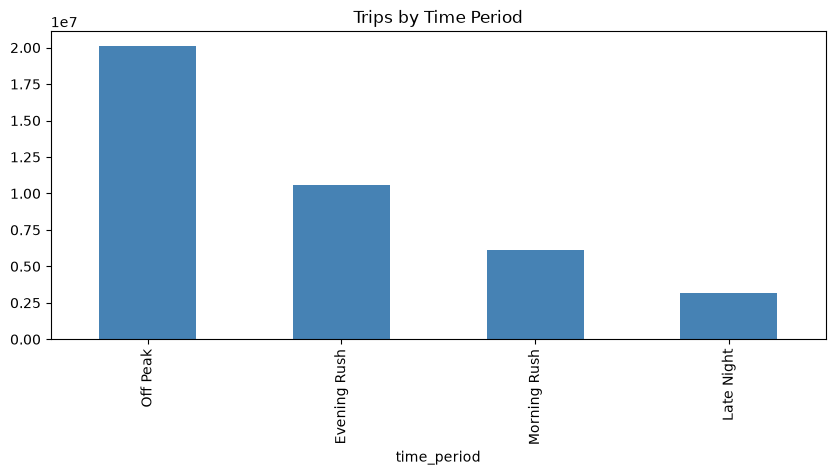

In [19]:
# Peak vs Off Peak
df_peak = conn.execute("""
    SELECT
        CASE 
            WHEN d.hour BETWEEN 7 AND 10 THEN 'Morning Rush'
            WHEN d.hour BETWEEN 16 AND 19 THEN 'Evening Rush'
            WHEN d.hour BETWEEN 0 AND 5 THEN 'Late Night'
            ELSE 'Off Peak'
        END AS time_period,
        COUNT(*) AS trips,
        ROUND(AVG(f.fare_amount), 2) AS avg_fare
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY time_period
    ORDER BY trips DESC
""").df()

display(df_peak)

df_peak.plot(x='time_period', y='trips', kind='bar', figsize=(10,4),
             title='Trips by Time Period', legend=False,
             color='steelblue')


### Geographic flows

In [31]:
# Top 10 Pickup Zones
df_pickup = conn.execute("""
    SELECT z.zone_name, z.borough, COUNT(*) AS pickups
    FROM fact_trips f
    JOIN dim_zone z ON f.pickup_zone_key = z.zone_id
    WHERE f.is_dirty = 0
    GROUP BY z.zone_name, z.borough
    ORDER BY pickups DESC
    LIMIT 10
""").df()

display(df_pickup)

,zone_name,borough,pickups
0,JFK Airport,Queens,1860596
1,Upper East Side South,Manhattan,1850932
2,Midtown Center,Manhattan,1842426
3,Upper East Side North,Manhattan,1676026
4,Midtown East,Manhattan,1367324
5,Times Sq/Theatre District,Manhattan,1324880
6,Penn Station/Madison Sq West,Manhattan,1308992
7,Lincoln Square East,Manhattan,1266440
8,LaGuardia Airport,Queens,1252010
9,Murray Hill,Manhattan,1128680


In [32]:
# Top 10 Dropoff Zones
df_pickup = conn.execute("""
    SELECT z.zone_name, z.borough, COUNT(*) AS dropoffs
    FROM fact_trips f
    JOIN dim_zone z ON f.dropoff_zone_key = z.zone_id
    WHERE f.is_dirty = 0
    GROUP BY z.zone_name, z.borough
    ORDER BY dropoffs DESC
    LIMIT 10;

""").df()

display(df_pickup)

,zone_name,borough,dropoffs
0,Upper East Side North,Manhattan,1768239
1,Upper East Side South,Manhattan,1675525
2,Midtown Center,Manhattan,1480913
3,Times Sq/Theatre District,Manhattan,1246263
4,Murray Hill,Manhattan,1167752
5,Midtown East,Manhattan,1140597
6,Lincoln Square East,Manhattan,1107881
7,Upper West Side South,Manhattan,1107514
8,Lenox Hill West,Manhattan,1033651
9,East Chelsea,Manhattan,1032182


In [35]:
df_borough = conn.execute("""
    SELECT pz.borough AS from_borough, dz.borough AS to_borough, COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_zone pz ON f.pickup_zone_key = pz.zone_id
    JOIN dim_zone dz ON f.dropoff_zone_key = dz.zone_id
    WHERE f.is_dirty = 0
    GROUP BY from_borough, to_borough
    ORDER BY trips DESC
    ;
""").df()

display(df_borough)

,from_borough,to_borough,trips
0,Manhattan,Manhattan,33105567
1,Queens,Manhattan,2117642
2,Manhattan,Queens,1077595
3,Queens,Queens,902788
4,Manhattan,Brooklyn,737823
...,...,...,...
59,EWR,Brooklyn,6
60,Staten Island,Bronx,6
61,EWR,Staten Island,5
62,Staten Island,Unknown,4


In [38]:
# Airport Trips
df_airport = conn.execute("""
    SELECT 
        z.zone_name AS airport,
        z.borough,
        COUNT(*) AS trips,
        ROUND(AVG(f.fare_amount), 2) AS avg_fare,
        ROUND(AVG(f.tip_pct), 2) AS avg_tip_pct
    FROM fact_trips f
    JOIN dim_zone z ON f.pickup_zone_key = z.zone_id
    WHERE f.is_airport_trip = 1
    AND f.is_dirty = 0
    GROUP BY z.zone_name, z.borough
    ORDER BY trips DESC
""").df()

display(df_airport)

,airport,borough,trips,avg_fare,avg_tip_pct
0,JFK Airport,Queens,1860596,64.25,14.62
1,LaGuardia Airport,Queens,1252010,44.15,21.56
2,Times Sq/Theatre District,Manhattan,107576,63.98,18.11
3,Midtown Center,Manhattan,71919,61.31,19.99
4,Midtown North,Manhattan,49547,64.21,19.01
...,...,...,...,...,...
246,Heartland Village/Todt Hill,Staten Island,1,135.00,20.15
247,Crotona Park,Bronx,1,40.06,0.00
248,Charleston/Tottenville,Staten Island,1,46.40,23.88
249,Rikers Island,Bronx,1,4.40,0.00


### PRICING AND TIPPING

In [40]:
# Fare per mile and per minute
df_airport = conn.execute("""
    SELECT ROUND(AVG(fare_per_mile), 2) AS avg_fare_per_mile,
    ROUND(AVG(fare_per_minute), 2) AS avg_fare_per_minute
    FROM fact_trips
    WHERE is_dirty = 0;
""").df()

display(df_airport)

,avg_fare_per_mile,avg_fare_per_minute
0,13.66,1.9


,payment_type,trips,avg_tip_pct,avg_tip_amount
0,Credit Card,30276996,25.06,4.35
1,Cash,5385511,0.00,0.00
2,Other,3719085,3.73,0.82
3,Dispute,386915,0.06,0.01
4,No Charge,151494,0.06,0.01
5,Unknown,22,0.00,0.00


<Axes: title={'center': 'Average Tip % by Payment Type'}, xlabel='payment_type'>

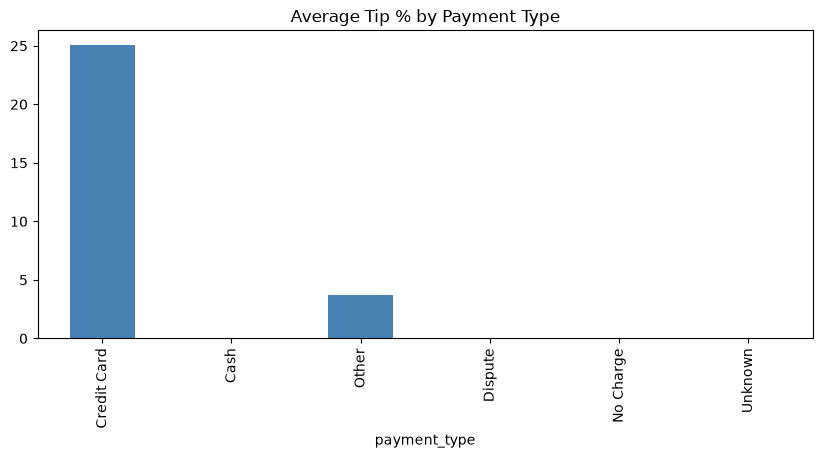

In [42]:
# Tip % by Payment Type 
df_tip = conn.execute("""
    SELECT
    CASE payment_key
        WHEN 1 THEN 'Credit Card'
        WHEN 2 THEN 'Cash'
        WHEN 3 THEN 'No Charge'
        WHEN 4 THEN 'Dispute'
        WHEN 5 THEN 'Unknown'
        WHEN 6 THEN 'Voided Trip'
        ELSE 'Other'
    END AS payment_type,
    COUNT(*) AS trips,
    ROUND(AVG(tip_pct), 2) AS avg_tip_pct,
    ROUND(AVG(tip_amount), 2) AS avg_tip_amount
    FROM fact_trips
    WHERE is_dirty = 0
    GROUP BY payment_key
    ORDER BY trips DESC
""").df()

display(df_tip)

df_tip.plot(x='payment_type', y='avg_tip_pct', kind='bar', figsize=(10,4),
            title='Average Tip % by Payment Type', legend=False,
            color='steelblue')

In [43]:
# Congestion Surcharge Impact
df_surcharge = conn.execute("""
    SELECT
    CASE WHEN congestion_surcharge > 0 THEN 'With Surcharge' 
        ELSE 'Without Surcharge' 
    END AS surcharge_type,
    COUNT(*) AS trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(total_amount), 2) AS avg_total,
    ROUND(AVG(tip_pct), 2) AS avg_tip_pct
    FROM fact_trips
    WHERE is_dirty = 0
    GROUP BY surcharge_type
""").df()

display(df_surcharge)

,surcharge_type,trips,avg_fare,avg_total,avg_tip_pct
0,With Surcharge,33169842,17.97,27.09,21.52
1,Without Surcharge,6750181,28.80,35.99,8.75


In [44]:
# Fare Distribution by Trip Distance Bucket
df_fare_dist = conn.execute("""
    SELECT
    CASE 
        WHEN trip_distance < 1 THEN 'Under 1 mile'
        WHEN trip_distance BETWEEN 1 AND 3 THEN '1-3 miles'
        WHEN trip_distance BETWEEN 3 AND 5 THEN '3-5 miles'
        WHEN trip_distance BETWEEN 5 AND 10 THEN '5-10 miles'
        ELSE 'Over 10 miles'
    END AS distance_bucket,
    COUNT(*) AS trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(fare_per_mile), 2) AS avg_fare_per_mile
    FROM fact_trips
    WHERE is_dirty = 0
    AND trip_distance > 0
    GROUP BY distance_bucket
    ORDER BY avg_fare
""").df()

display(df_fare_dist)

,distance_bucket,trips,avg_fare,avg_fare_per_mile
0,Under 1 mile,8699740,8.32,37.55
1,1-3 miles,19766025,13.81,8.06
2,3-5 miles,4600250,23.17,6.13
3,5-10 miles,3600518,34.88,4.88
4,Over 10 miles,3247317,65.56,4.14


### Service Quality and anomalies

,speed_bucket,trips,pct
0,Under 5 mph,4786477,0.114466
1,5-20 mph,33443616,0.799785
2,20-40 mph,3420027,0.081788
3,40-60 mph,147513,0.003528
4,60-80 mph,2724,0.000065
5,80-120 mph,2264,0.000054
6,Over 120 mph (outlier),13143,0.000314


<Axes: title={'center': 'Trip Speed Distribution'}, xlabel='speed_bucket'>

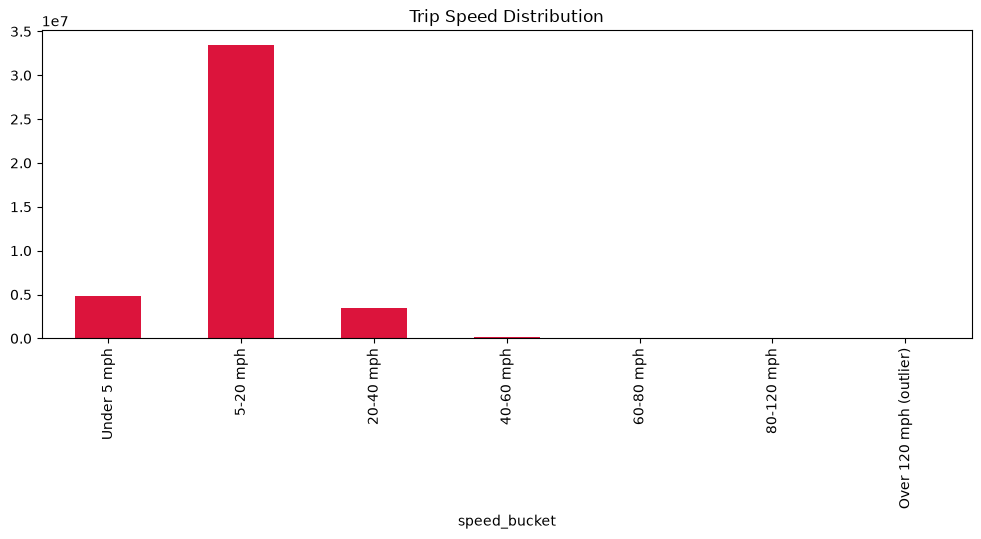

In [48]:
# trip speed outliers
df_speed = conn.execute("""
    SELECT 
    CASE WHEN speed_mph < 5 THEN 'Under 5 mph'
        WHEN speed_mph BETWEEN 5 AND 20 THEN '5-20 mph'
        WHEN speed_mph BETWEEN 20 AND 40 THEN '20-40 mph'
        WHEN speed_mph BETWEEN 40 AND 60 THEN '40-60 mph'
        WHEN speed_mph BETWEEN 60 AND 80 THEN '60-80 mph'
        WHEN speed_mph BETWEEN 80 AND 120 THEN '80-120 mph'
        ELSE 'Over 120 mph (outlier)'
    END AS speed_bucket,
    COUNT(*) AS trips,
    ROUND(COUNT(*) / SUM(COUNT(*)) OVER(), 6) AS pct
    FROM fact_trips
    WHERE speed_mph IS NOT NULL
    AND speed_mph >= 0
    GROUP BY speed_bucket
    ORDER BY MIN(speed_mph)
""").df()

display(df_speed)

df_speed.plot(x='speed_bucket', y='trips', kind='bar', figsize=(12,4),
              title='Trip Speed Distribution', legend=False,
              color='crimson')

In [51]:
# Dirty Record Share
df_dirty = conn.execute("""
    SELECT
        SUM(is_dirty) AS dirty_records,
        COUNT(*) AS total_records,
        ROUND(SUM(is_dirty) / COUNT(*), 4) AS dirty_pct
    FROM fact_trips
""").df()

display(df_dirty)

,dirty_records,total_records,dirty_pct
0,1909911.0,41829934,0.0457


In [25]:
#negative fare
df_neg_fare = conn.execute("""
    SELECT COUNT(*) AS negative_fares, 
    (SELECT COUNT(*) FROM fact_trips) AS total_fares,
    ROUND(COUNT(*)/(SELECT COUNT(*) FROM fact_trips), 4)
    FROM fact_trips
    WHERE fare_amount < 0;
""").df()

display(df_neg_fare)

,negative_fares,total_fares,"round((count_star() / (SELECT count_star() FROM fact_trips)), 4)"
0,733168,41829934,0.0175


In [77]:
#zero distance and zero fare tips
df_zero = conn.execute("""
    SELECT (SELECT COUNT(*) FROM fact_trips WHERE fare_amount = 0) zero_fare_trips,
    (SELECT COUNT(*) FROM fact_trips WHERE trip_distance = 0) zero_dist_trips,
    ROUND(COUNT(*)/(SELECT COUNT(*) FROM fact_trips), 4) AS zero_dist_or_fare_trips
    FROM fact_trips
    WHERE fare_amount = 0
    OR trip_distance = 0
""").df()

display(df_zero)

,zero_fare_trips,zero_dist_trips,zero_dist_or_fare_trips
0,17783,810877,0.0197


In [79]:
#implausible durations
df_duration = conn.execute("""
    SELECT * 
    FROM fact_trips
    ORDER BY trip_duration_min DESC
    LIMIT 15
""").df()

display(df_duration)

,date_key,pickup_zone_key,dropoff_zone_key,payment_key,service_type,fare_amount,tip_amount,tolls_amount,total_amount,trip_distance,passenger_count,congestion_surcharge,trip_duration_min,speed_mph,fare_per_mile,fare_per_minute,tip_pct,is_airport_trip,is_dirty,dirty_reason
0,2024040823,129,138,2.0,yellow,1.0,0.0,16.26,18.26,13.62,1.0,0.0,9767.516667,0.083665,0.073421,0.000102,0.0,1,1,duration_over_5hrs
1,2024101613,48,265,2.0,yellow,152.5,0.0,17.38,170.88,32.37,1.0,0.0,9757.066667,0.199056,4.711152,0.015630,0.0,0,1,duration_over_5hrs
2,2024072220,138,130,2.0,yellow,31.0,0.0,0.00,40.25,2.34,1.0,0.0,9670.283333,0.014519,13.247863,0.003206,0.0,1,1,duration_over_5hrs
3,2024012417,237,170,2.0,yellow,30.3,0.0,0.00,36.80,2.26,1.0,2.5,9455.400000,0.014341,13.407080,0.003205,0.0,0,1,duration_over_5hrs
4,2024032710,207,207,2.0,yellow,3.0,0.0,0.00,4.50,0.00,1.0,0.0,9092.550000,0.000000,NaN,0.000330,0.0,0,1,duration_over_5hrs
5,2024080106,207,14,2.0,yellow,3.0,0.0,0.00,4.50,0.00,1.0,0.0,9027.050000,0.000000,NaN,0.000332,0.0,0,1,duration_over_5hrs
6,2024080115,43,226,2.0,yellow,4.4,0.0,0.00,8.40,0.02,1.0,2.5,8757.600000,0.000137,220.000000,0.000502,0.0,0,1,duration_over_5hrs
7,2024100318,100,100,2.0,yellow,70.0,0.0,0.00,79.00,0.00,1.0,2.5,8599.500000,0.000000,NaN,0.008140,0.0,0,1,duration_over_5hrs
8,2024050212,207,207,2.0,yellow,3.0,0.0,0.00,4.50,0.00,1.0,0.0,8547.683333,0.000000,NaN,0.000351,0.0,0,1,duration_over_5hrs
9,2024102216,186,226,2.0,yellow,27.5,0.0,0.00,34.00,0.00,1.0,2.5,8265.633333,0.000000,NaN,0.003327,0.0,0,1,duration_over_5hrs


## Handling of Dirty records

### Trend and Seasonality

In [9]:
# Month-over-month ridership trend and seasonality
df_monthly_ridership = conn.execute("""
    SELECT d.month,
        d.month_name,
        COUNT(*) AS trips,
        ROUND(AVG(f.fare_amount), 2) AS avg_fare
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.month, d.month_name
    ORDER BY d.month
""").df()

display(df_monthly_ridership)

,month,month_name,trips,avg_fare
0,1,January,2889985,18.47
1,2,February,2916708,18.40
2,3,March,3453037,19.14
3,4,April,3427095,19.44
4,5,May,3635119,20.13
5,6,June,3443641,19.95
6,7,July,2992633,20.15
7,8,August,2889101,20.38
8,9,September,3504894,20.66
9,10,October,3699037,20.34


In [10]:
# Average Fare Trend by Month
df_fare_trend = conn.execute("""
    SELECT d.month_name,
        d.month,
        ROUND(AVG(f.fare_amount), 2) AS avg_fare,
        ROUND(AVG(f.fare_per_mile), 2) AS avg_fare_per_mile,
        ROUND(AVG(f.trip_distance), 2) AS avg_distance
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.month_name, d.month
    ORDER BY d.month
""").df()

display(df_fare_trend)

,month_name,month,avg_fare,avg_fare_per_mile,avg_distance
0,January,1,18.47,11.54,3.31
1,February,2,18.40,11.32,3.22
2,March,3,19.14,11.65,3.36
3,April,4,19.44,11.83,3.39
4,May,5,20.13,12.44,3.43
5,June,6,19.95,12.99,3.43
6,July,7,20.15,13.00,3.61
7,August,8,20.38,14.35,3.67
8,September,9,20.66,16.32,3.54
9,October,10,20.34,15.61,3.48


In [11]:
# Seasonality by Day of Week and Month
df_season = conn.execute("""
    SELECT d.month_name,
        d.month,
        d.day_name,
        COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.month_name, d.month, d.day_name
    ORDER BY d.month
""").df()

display(df_season)

,month_name,month,day_name,trips
0,January,1,Thursday,419386
1,January,1,Wednesday,485129
2,January,1,Monday,396425
3,January,1,Sunday,327798
4,January,1,Tuesday,453067
...,...,...,...,...
79,December,12,Monday,503688
80,December,12,Saturday,508050
81,December,12,Friday,510683
82,December,12,Thursday,506301


,month,month_name,trips
0,1,January,2889985
1,2,February,2916708
2,3,March,3453037
3,4,April,3427095
4,5,May,3635119
5,6,June,3443641
6,7,July,2992633
7,8,August,2889101
8,9,September,3504894
9,10,October,3699037


<Axes: title={'center': 'Ridership Trend — 2024'}, xlabel='month_name'>

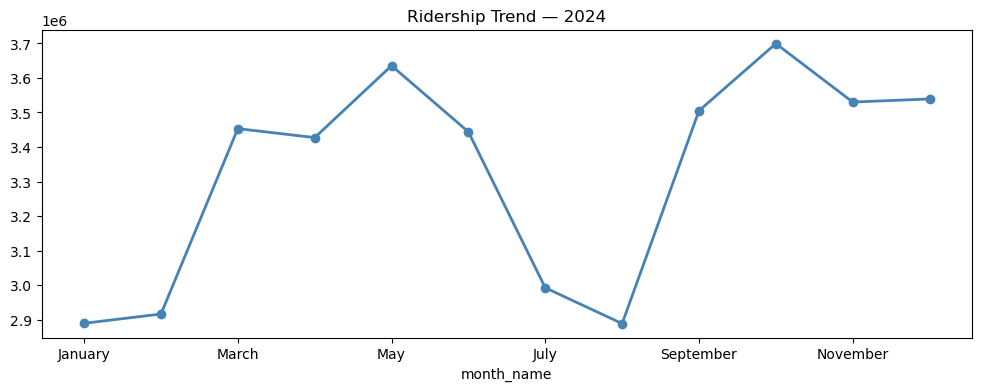

In [12]:
# Ridership Trend Line
df_trend = conn.execute("""
    SELECT
        d.month,
        d.month_name,
        COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.is_dirty = 0
    GROUP BY d.month, d.month_name
    ORDER BY d.month
""").df()

display(df_trend)

df_trend.plot(x='month_name', y='trips', kind='line', figsize=(12,4),
              title='Ridership Trend — 2024', legend=False,
              color='steelblue', marker='o', linewidth=2)

In [13]:
conn.execute("""
    COPY (
        SELECT f.*, 
               d.hour, d.day_name, d.month_name, d.month, d.is_weekend,
               pz.zone_name AS pickup_zone, pz.borough AS pickup_borough,
               dz.zone_name AS dropoff_zone, dz.borough AS dropoff_borough
        FROM fact_trips f
        JOIN dim_date d ON f.date_key = d.date_key
        JOIN dim_zone pz ON f.pickup_zone_key = pz.zone_id
        JOIN dim_zone dz ON f.dropoff_zone_key = dz.zone_id
    ) TO '../dashboard/fact_trips_dashboard.csv' (HEADER, DELIMITER ',')
""")

print("Exported successfully")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Exported successfully


In [6]:
conn.execute("""
    COPY (
        SELECT 
            d.hour,
            d.day_name,
            d.day_of_week,
            d.month_name,
            d.month,
            d.is_weekend,
            pz.zone_name AS pickup_zone,
            pz.borough AS pickup_borough,
            dz.zone_name AS dropoff_zone,
            dz.borough AS dropoff_borough,
            f.service_type,
            f.payment_key,
            f.fare_amount,
            f.tip_amount,
            f.total_amount,
            f.trip_distance,
            f.trip_duration_min,
            f.fare_per_mile,
            f.tip_pct,
            f.is_airport_trip,
            f.is_dirty,
            f.congestion_surcharge
        FROM fact_trips f
        JOIN dim_date d ON f.date_key = d.date_key
        JOIN dim_zone pz ON f.pickup_zone_key = pz.zone_id
        JOIN dim_zone dz ON f.dropoff_zone_key = dz.zone_id
    ) TO '../dashboard/fact_trips_dashboard.csv' (HEADER, DELIMITER ',')
""")

print("Exported successfully")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Exported successfully


In [7]:
# Export pre-aggregated summary for dashboard
conn.execute("""
    COPY (
        SELECT 
            d.hour,
            d.day_name,
            d.day_of_week,
            d.month_name,
            d.month,
            d.is_weekend,
            pz.borough AS pickup_borough,
            dz.borough AS dropoff_borough,
            f.service_type,
            f.is_airport_trip,
            f.is_dirty,
            COUNT(*) AS trips,
            ROUND(AVG(f.fare_amount), 2) AS avg_fare,
            ROUND(AVG(f.tip_pct), 2) AS avg_tip_pct,
            ROUND(AVG(f.fare_per_mile), 2) AS avg_fare_per_mile,
            ROUND(AVG(f.trip_distance), 2) AS avg_distance,
            ROUND(AVG(f.congestion_surcharge), 2) AS avg_surcharge
        FROM fact_trips f
        JOIN dim_date d ON f.date_key = d.date_key
        JOIN dim_zone pz ON f.pickup_zone_key = pz.zone_id
        JOIN dim_zone dz ON f.dropoff_zone_key = dz.zone_id
        GROUP BY d.hour, d.day_name, d.day_of_week, d.month_name, d.month,
                 d.is_weekend, pz.borough, dz.borough, f.service_type,
                 f.is_airport_trip, f.is_dirty
    ) TO '../dashboard/fact_trips_summary.csv' (HEADER, DELIMITER ',')
""")

print("Exported successfully")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Exported successfully


In [7]:
df_avg = conn.execute("""
    SELECT * FROM fact_trips LIMIT 10
""").df()

display(df_avg)

,date_key,pickup_zone_key,dropoff_zone_key,payment_key,service_type,fare_amount,tip_amount,tolls_amount,total_amount,trip_distance,passenger_count,congestion_surcharge,trip_duration_min,speed_mph,fare_per_mile,fare_per_minute,tip_pct,is_airport_trip,is_dirty,dirty_reason
0,2024070100,80,100,1.0,green,38.0,2.00,0.0,45.25,8.20,2.0,2.75,30.266667,16.255507,4.634146,1.255507,5.263158,0,0,None
1,2024070100,66,89,1.0,green,36.6,7.82,0.0,46.92,7.87,1.0,0.00,25.866667,18.255155,4.650572,1.414948,21.366120,0,0,None
2,2024070100,129,260,2.0,green,8.6,0.00,0.0,11.10,0.96,1.0,0.00,9.383333,6.138544,8.958333,0.916519,0.000000,0,0,None
3,2024070100,42,120,1.0,green,24.0,0.00,0.0,26.50,5.73,1.0,0.00,12.116667,28.374140,4.188482,1.980743,0.000000,0,0,None
4,2024070100,152,185,1.0,green,35.2,11.31,0.0,49.01,8.62,1.0,0.00,20.083333,25.752697,4.083527,1.752697,32.130682,0,0,None
5,2024063023,66,79,1.0,green,24.0,5.85,0.0,35.10,4.75,2.0,2.75,18.766667,15.186501,5.052632,1.278863,24.375000,0,0,None
6,2024070100,129,129,1.0,green,5.8,5.00,0.0,13.30,0.54,1.0,0.00,4.400000,7.363636,10.740741,1.318182,86.206897,0,0,None
7,2024070100,129,157,1.0,green,10.0,6.34,0.0,18.84,1.15,1.0,0.00,8.300000,8.313253,8.695652,1.204819,63.400000,0,0,None
8,2024070100,132,132,1.0,green,30.0,0.00,0.0,31.00,0.01,1.0,0.00,0.066667,9.000000,3000.000000,450.000000,0.000000,1,0,None
9,2024070100,130,139,1.0,green,28.9,0.00,0.0,31.40,6.73,1.0,0.00,15.483333,26.079656,4.294205,1.866523,0.000000,0,0,None


In [5]:
df_all = conn.execute("""
    SELECT *
    FROM fact_trips
    LIMIT 10
""").df()

display(df_all)

,date_key,pickup_zone_key,dropoff_zone_key,payment_key,service_type,fare_amount,tip_amount,tolls_amount,total_amount,trip_distance,passenger_count,congestion_surcharge,trip_duration_min,speed_mph,fare_per_mile,fare_per_minute,tip_pct,is_airport_trip,is_dirty,dirty_reason
0,2024070100,80,100,1.0,green,38.0,2.00,0.0,45.25,8.20,2.0,2.75,30.266667,16.255507,4.634146,1.255507,5.263158,0,0,None
1,2024070100,66,89,1.0,green,36.6,7.82,0.0,46.92,7.87,1.0,0.00,25.866667,18.255155,4.650572,1.414948,21.366120,0,0,None
2,2024070100,129,260,2.0,green,8.6,0.00,0.0,11.10,0.96,1.0,0.00,9.383333,6.138544,8.958333,0.916519,0.000000,0,0,None
3,2024070100,42,120,1.0,green,24.0,0.00,0.0,26.50,5.73,1.0,0.00,12.116667,28.374140,4.188482,1.980743,0.000000,0,0,None
4,2024070100,152,185,1.0,green,35.2,11.31,0.0,49.01,8.62,1.0,0.00,20.083333,25.752697,4.083527,1.752697,32.130682,0,0,None
5,2024063023,66,79,1.0,green,24.0,5.85,0.0,35.10,4.75,2.0,2.75,18.766667,15.186501,5.052632,1.278863,24.375000,0,0,None
6,2024070100,129,129,1.0,green,5.8,5.00,0.0,13.30,0.54,1.0,0.00,4.400000,7.363636,10.740741,1.318182,86.206897,0,0,None
7,2024070100,129,157,1.0,green,10.0,6.34,0.0,18.84,1.15,1.0,0.00,8.300000,8.313253,8.695652,1.204819,63.400000,0,0,None
8,2024070100,132,132,1.0,green,30.0,0.00,0.0,31.00,0.01,1.0,0.00,0.066667,9.000000,3000.000000,450.000000,0.000000,1,0,None
9,2024070100,130,139,1.0,green,28.9,0.00,0.0,31.40,6.73,1.0,0.00,15.483333,26.079656,4.294205,1.866523,0.000000,0,0,None
